In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import itertools as it
import statistics as stat
import json
#from wpb_tools import *

In [2]:
# angle bounds for determining cis vs trans configurations

cislower = -90
cisupper = 50
translower = 100
transupper = 240

# NOTE: This variable was originally created for looking at the unreweighted data, but was abandoned
# partway through the notebook to focus on the reweighted data
has_weights = 1 # 0 = no, unreweighted data; 1 = yes, reweighted data

nsim = 10 # number of simulations

In [3]:
params = [{'sep':r'\s+', 'low_memory':False}, {'engine':'c'}][0]

ctd_secstruc = pd.read_table('/data/mcohen3/CTD/asparagine/s5n7/analysis/turn/ctd_sec.out', **params)
ctd_phos_secstruc = pd.read_table('/data/mcohen3/CTD/asparagine/ps5n7/analysis/turn/ctd_p_sec.out', **params)

In [4]:
ctd_phos_secstruc.head()

,#Frame,ACE:1,TYR:2,SER:3,PRO:4,THR:5,SEP:6,PRO:7,SER:8,TYR:9,...,PRO:14,ASN:15,TYR:16,SER:17,PRO:18,THR:19,SEP:20,PRO:21,SER:22,NHE:23
0,1,0,B,0,0,S,S,S,0,S,...,T,T,0,B,0,0,0,0,0,0
1,2,0,B,0,0,S,S,S,S,S,...,T,T,0,B,0,0,0,0,0,0
2,3,0,0,0,0,0,S,S,0,S,...,T,T,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,S,S,S,S,...,H,H,0,0,0,0,0,0,0,0
4,5,0,0,0,0,0,S,S,S,S,...,T,S,0,0,0,0,0,0,0,0


In [5]:

ctd_omega_angles_raw = pd.read_table('/data/mcohen3/CTD/asparagine/s5n7/analysis/turn/ctd_dihedral_Omega.dat', sep = r'\s+')
ctd_phos_omega_angles_raw = pd.read_table('/data/mcohen3/CTD/asparagine/ps5n7/analysis/turn/ctd_dihedral_Omega.dat', sep = r'\s+')

In [6]:
# Weights (unphos)

if has_weights ==1:
    ctd_weights_combined_raw = pd.read_table('/data/mcohen3/CTD/asparagine/s5n7/reweighting/weights_by_frame_MC-order10.dat', header=None)
    p_ctd_weights_combined_raw = pd.read_table('/data/mcohen3/CTD/asparagine/ps5n7/reweighting/weights_by_frame_MC-order10.dat', header=None)

In [7]:
if has_weights == 1:
    ctd_weights_combined = ctd_weights_combined_raw/ctd_weights_combined_raw.sum()
    p_ctd_weights_combined = p_ctd_weights_combined_raw/p_ctd_weights_combined_raw.sum()

In [8]:
# function for computing means and sems of datasets

def turn_plot_mean_sem(has_weights, data, nsim): # (INCLUDE DATA TYPES)Weighted: yes, reweighted = 1, no, not reweighted = 0, data = dataset, nsim = # of simulations
    # if reweighted
    if has_weights == 1:
        dfs = np.array_split(data, nsim)
        sums = [part.sum() for part in dfs]
        sum_df = pd.DataFrame(sums, index=[f'sim{i}' for i in range(nsim)])*nsim
        # Calculate the mean and standard deviation for each DataFrame in 'dfs'
        means = sum_df.mean()
        sems = sum_df.sem()
        # Add the mean and std deviation as new rows in the sum_df DataFrame
        sum_df.loc['mean'] = means
        sum_df.loc['sem'] = sems
        ctd = sum_df
        
    # if not reweighted
    else: #COMMENT THIS TO MAKE MORE SENSE FOR UNREWEIGHTED
        dfs = np.array_split(data, nsim) 
        sums = [part.mean() for part in dfs]
        sum_df = pd.DataFrame(sums, index=[f'sim{i}' for i in range(nsim)])
        # Calculate the mean and standard deviation for each DataFrame in 'dfs'
        means = sum_df.mean()
        sems = sum_df.sem()
        # Add the mean and std deviation as new rows in the sum_df DataFrame
        sum_df.loc['mean'] = means
        sum_df.loc['sem'] = sems
        ctd = sum_df
    
    return sum_df

In [9]:
if has_weights == 1:
    # Make sure both DataFrames and Series are aligned
    p_frame_col = ctd_phos_secstruc["#Frame"].reset_index(drop=True)
    ctd_phos_secstruc_reweighted = (
        (ctd_phos_secstruc.drop(columns="#Frame") == "T")
        .mul(p_ctd_weights_combined[0].values, axis=0)
        .reset_index(drop=True)
    )
    # Insert frame column
    ctd_phos_secstruc_reweighted["#Frame"] = p_frame_col
else:
    ctd_phos_inturn = ctd_phos_secstruc == "T"

In [10]:
if has_weights == 1:
    # Make sure both DataFrames and Series are aligned
    frame_col = ctd_secstruc["#Frame"].reset_index(drop=True)
    ctd_secstruc_reweighted = (
        (ctd_secstruc.drop(columns="#Frame") == "T")
        .mul(ctd_weights_combined[0].values, axis=0)
        .reset_index(drop=True)
    )
    # Insert frame column
    ctd_secstruc_reweighted["#Frame"] = frame_col
else:
    ctd_inturn = ctd_secstruc == "T"

In [11]:
# compute means and sems

if has_weights == 1:
    ctd = turn_plot_mean_sem(has_weights, ctd_secstruc_reweighted, nsim)
    ctd_phos = turn_plot_mean_sem(has_weights, ctd_phos_secstruc_reweighted, nsim)
else:    
    ctd = turn_plot_mean_sem(has_weights, ctd_inturn, nsim)
    ctd_phos = turn_plot_mean_sem(has_weights, ctd_phos_inturn, nsim)

/cm/shared/apps/anaconda3/python3.12/lib/python3.12/site-packages/numpy/core/fromnumeric.py:59: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)
/cm/shared/apps/anaconda3/python3.12/lib/python3.12/site-packages/numpy/core/fromnumeric.py:59: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


In [12]:
whole_ctd = ctd.loc[['mean']].iloc[:,1:22]
whole_ctd_p = ctd_phos.loc[['mean']].iloc[:,1:22]
whole_ctd_sem = ctd.loc[['sem']].iloc[:,1:22]
whole_ctd_p_sem = ctd_phos.loc[['sem']].iloc[:,1:22]

In [13]:
mid_ctd = whole_ctd.iloc[:,7:14]
mid_ctd_p = whole_ctd_p.iloc[:,7:14]
mid_ctd_sem = whole_ctd_sem.iloc[:,7:14]
mid_ctd_p_sem = whole_ctd_p_sem.iloc[:,7:14]

In [14]:
# Check the mean percentage of turn across all residues
whole_ctd.mean(axis = 1)

mean    0.103965
dtype: float64

In [15]:
whole_ctd_p.mean(axis = 1)

mean    0.10241
dtype: float64

In [16]:
mid_ctd

,TYR:9,SER:10,PRO:11,THR:12,SER:13,PRO:14,ASN:15
mean,0.118582,0.073084,0.18565,0.164675,0.068385,0.133863,0.125636


In [17]:
mid_ctd_sem

,TYR:9,SER:10,PRO:11,THR:12,SER:13,PRO:14,ASN:15
sem,0.008229,0.007806,0.012023,0.01244,0.006218,0.008309,0.007232


In [18]:
mid_ctd_p

,TYR:9,SER:10,PRO:11,THR:12,SEP:13,PRO:14,ASN:15
mean,0.107115,0.023377,0.072239,0.086966,0.190496,0.232146,0.149749


In [19]:
mid_ctd_p_sem

,TYR:9,SER:10,PRO:11,THR:12,SEP:13,PRO:14,ASN:15
sem,0.00762,0.003335,0.004778,0.004906,0.011592,0.012586,0.010844


In [20]:
def weighted_mean_and_se(values, weights):
    """
    Calculates the weighted mean and its standard error.

    Args:
        values (array-like): The data values.
        weights (array-like): The corresponding weights for each value.

    Returns:
        tuple: A tuple containing the weighted mean and the standard error of the weighted mean.
    """
    values = np.array(values)
    weights = np.array(weights)

    if len(values) != len(weights):
        raise ValueError("Values and weights must have the same length.")

    # Create a boolean mask to find non-NaN values in both data and weights.
    valid_mask = ~np.isnan(values) & ~np.isnan(weights)
    
    # Filter the data and weights to keep only valid entries.
    valid_data = values[valid_mask]
    valid_weights = weights[valid_mask]

    # Calculate the weighted mean
    weighted_mean = np.average(valid_data, weights=valid_weights)

    # Calculate the weighted variance
    # For sample variance, adjust for degrees of freedom (n-1)
    # The denominator for weighted variance is typically sum(weights) - (sum(weights^2) / sum(weights))
    # or a simpler form for large samples. Here we use a common form for sample weighted variance.
    sum_of_weights = np.sum(valid_weights)
    weighted_variance = np.sum(valid_weights * (valid_data - weighted_mean)**2) / (sum_of_weights - (np.sum(valid_weights**2) / sum_of_weights))

    # Calculate the standard error of the weighted mean
    # SE = sqrt(weighted_variance / effective_sample_size)
    # Effective sample size can be considered as (sum_of_weights)^2 / sum(weights^2)
    effective_sample_size = (sum_of_weights**2) / np.sum(valid_weights**2)
    standard_error = np.sqrt(weighted_variance / effective_sample_size)

    return weighted_mean, standard_error

Current dimensions: 6.4 x 4.8 inches
New dimensions: 3.25 x 2.4374999999999996 inches


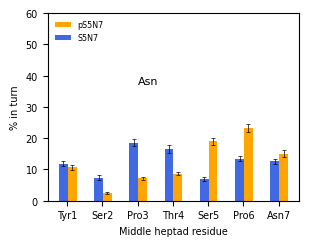

In [22]:
plt.figure()

x = ["Tyr1","Ser2","Pro3","Thr4","Ser5","Pro6","Asn7"]

x_axis = np.arange(len(x))

plt.bar(x_axis + 0.14, mid_ctd_p.iloc[0]*100, 0.25, yerr = mid_ctd_p_sem.iloc[0]*100, error_kw={'elinewidth': 0.5, "capsize": 1.5, "capthick": 0.5}, label='pS5N7', color='orange')
plt.bar(x_axis - 0.11, mid_ctd.iloc[0]*100, 0.25, yerr = mid_ctd_sem.iloc[0]*100, error_kw={'elinewidth': 0.5, "capsize": 1.5, "capthick": 0.5}, label='S5N7', color='royalblue')
#yerr=np.array(list(unphos_std.values()))*100
plt.xticks(x_axis, x, fontsize = 7)
plt.yticks(fontsize = 7)
plt.legend(loc = "upper left", fontsize = 5.75, frameon=False)
plt.ylabel("% in turn", fontsize = 7)
plt.xlabel("Middle heptad residue", fontsize = 7)
plt.text(2, 40, 'Asn', fontsize=8, verticalalignment='top')
plt.ylim(top=60)  
plt.ylim(bottom=0)
#plt.title("CTD Turn Character")

# Get the current figure
fig = plt.gcf()

# Get the current dimensions
current_width, current_height = fig.get_size_inches()
print(f"Current dimensions: {current_width} x {current_height} inches")

# Define the new width
new_width = 3.25

# Calculate the new height to maintain the aspect ratio
aspect_ratio = current_height / current_width
new_height = new_width * aspect_ratio
print(f"New dimensions: {new_width} x {new_height} inches")

# Set the new figure size
fig.set_size_inches(new_width, new_height)

# Save the figure
plt.savefig('asn_turn_3.25in.png', dpi=300, bbox_inches='tight')

plt.show()

In [23]:
df_360 = ctd_omega_angles_raw.copy()
# loop through columns to convert numbers below -90
for col in df_360:
    df_360.loc[df_360[col] < -90, col] += 360  # Convert negative angles to a 0-360 range
    df_360[col] = round(df_360[col])  # Round angles to the nearest integer

In [24]:
df_360.head()

,#Frame,omega:3,omega:4,omega:5,omega:6,omega:7,omega:8,omega:9,omega:10,omega:11,...,omega:13,omega:14,omega:15,omega:16,omega:17,omega:18,omega:19,omega:20,omega:21,omega:22
0,1,173.0,181.0,227.0,95.0,202.0,207.0,190.0,180.0,163.0,...,241.0,196.0,182.0,203.0,175.0,185.0,178.0,200.0,165.0,-8.0
1,2,184.0,188.0,242.0,105.0,195.0,187.0,166.0,179.0,170.0,...,223.0,190.0,193.0,206.0,188.0,178.0,189.0,201.0,153.0,-5.0
2,3,186.0,180.0,230.0,118.0,213.0,196.0,174.0,179.0,171.0,...,215.0,180.0,188.0,202.0,187.0,193.0,189.0,200.0,157.0,-39.0
3,4,184.0,185.0,218.0,131.0,205.0,197.0,184.0,184.0,178.0,...,225.0,182.0,193.0,206.0,184.0,188.0,192.0,201.0,173.0,-45.0
4,5,187.0,202.0,222.0,128.0,199.0,184.0,173.0,178.0,171.0,...,220.0,174.0,194.0,197.0,186.0,198.0,176.0,199.0,180.0,-22.0


In [25]:
df_360_phos = ctd_phos_omega_angles_raw # Create a new column to hold the 360-degree adjusted omega values
# loop through columns to convert numbers below -90
for col in df_360_phos:
    df_360_phos.loc[df_360_phos[col] < -90, col] += 360  # Convert negative angles to a 0-360 range
    df_360_phos[col] = round(df_360_phos[col])  # Round angles to the nearest integer

In [26]:
# retaining omega angle values
ctd_phos_omega_angles = df_360_phos.copy()
ctd_omega_angles = df_360.copy()

In [27]:
ctd_phos_omega_angles.head()

,#Frame,omega:3,omega:4,omega:5,omega:6,omega:7,omega:8,omega:9,omega:10,omega:11,...,omega:13,omega:14,omega:15,omega:16,omega:17,omega:18,omega:19,omega:20,omega:21,omega:22
0,1,169.0,155.0,178.0,201.0,245.0,199.0,152.0,186.0,144.0,...,192.0,147.0,174.0,199.0,196.0,139.0,179.0,187.0,-79.0,197.0
1,2,192.0,162.0,190.0,194.0,230.0,205.0,156.0,183.0,148.0,...,177.0,163.0,156.0,192.0,193.0,126.0,154.0,195.0,-51.0,177.0
2,3,189.0,160.0,185.0,186.0,231.0,198.0,161.0,171.0,155.0,...,186.0,154.0,176.0,196.0,204.0,137.0,157.0,190.0,-54.0,159.0
3,4,156.0,154.0,197.0,187.0,217.0,210.0,167.0,154.0,150.0,...,189.0,154.0,172.0,180.0,182.0,142.0,174.0,193.0,-18.0,168.0
4,5,156.0,142.0,199.0,186.0,221.0,196.0,167.0,146.0,153.0,...,175.0,159.0,182.0,170.0,195.0,148.0,164.0,173.0,-37.0,179.0


In [28]:
df_360[ctd_omega_angles['#Frame'] == 18+4900000*3]

,#Frame,omega:3,omega:4,omega:5,omega:6,omega:7,omega:8,omega:9,omega:10,omega:11,...,omega:13,omega:14,omega:15,omega:16,omega:17,omega:18,omega:19,omega:20,omega:21,omega:22
14700017,14700018,188.0,175.0,154.0,168.0,184.0,151.0,187.0,175.0,-5.0,...,193.0,-4.0,194.0,148.0,151.0,147.0,197.0,169.0,147.0,163.0


In [29]:
# labelling configurationgs of omega angles
temp_angles = ctd_phos_omega_angles.copy()

ctd_phos_omega_angles[(temp_angles.iloc[:,1:] >= cislower) & (temp_angles.iloc[:,1:] <= cisupper)] = "cis"
ctd_phos_omega_angles[(temp_angles.iloc[:,1:] >= translower) & (temp_angles.iloc[:,1:] <= transupper)] = "trans"
ctd_phos_omega_angles[(ctd_phos_omega_angles.iloc[:,1:] != "cis") & (ctd_phos_omega_angles.iloc[:,1:] != "trans")] = "neither"

temp_angles = ctd_omega_angles.copy()

ctd_omega_angles[(temp_angles.iloc[:,1:] >= cislower) & (temp_angles.iloc[:,1:] <= cisupper)] = "cis"
ctd_omega_angles[(temp_angles.iloc[:,1:] >= translower) & (temp_angles.iloc[:,1:] <= transupper)] = "trans"
ctd_omega_angles[(ctd_omega_angles.iloc[:,1:] != "cis") & (ctd_omega_angles.iloc[:,1:] != "trans")] = "neither"

/tmp/ipykernel_2240205/3590104210.py:4: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'cis' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  ctd_phos_omega_angles[(temp_angles.iloc[:,1:] >= cislower) & (temp_angles.iloc[:,1:] <= cisupper)] = "cis"
/tmp/ipykernel_2240205/3590104210.py:10: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'cis' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  ctd_omega_angles[(temp_angles.iloc[:,1:] >= cislower) & (temp_angles.iloc[:,1:] <= cisupper)] = "cis"


In [30]:
ctd_omega_angles = ctd_omega_angles.reset_index(drop = True)

In [31]:
ctd_omega_angles['weights'] = ctd_weights_combined[0]

In [32]:
ctd_phos_omega_angles['weights'] = p_ctd_weights_combined[0]

In [33]:
ctd_phos_omega_angles.head()

,#Frame,omega:3,omega:4,omega:5,omega:6,omega:7,omega:8,omega:9,omega:10,omega:11,...,omega:14,omega:15,omega:16,omega:17,omega:18,omega:19,omega:20,omega:21,omega:22,weights
0,1,trans,trans,trans,trans,neither,trans,trans,trans,trans,...,trans,trans,trans,trans,trans,trans,trans,cis,trans,3.353254e-08
1,2,trans,trans,trans,trans,trans,trans,trans,trans,trans,...,trans,trans,trans,trans,trans,trans,trans,cis,trans,1.815629e-08
2,3,trans,trans,trans,trans,trans,trans,trans,trans,trans,...,trans,trans,trans,trans,trans,trans,trans,cis,trans,1.478031e-08
3,4,trans,trans,trans,trans,trans,trans,trans,trans,trans,...,trans,trans,trans,trans,trans,trans,trans,cis,trans,1.911366e-08
4,5,trans,trans,trans,trans,trans,trans,trans,trans,trans,...,trans,trans,trans,trans,trans,trans,trans,cis,trans,2.361327e-08


In [37]:
ctd_weights_combined

,0
0,5.568765e-09
1,1.472184e-08
2,9.697759e-09
3,3.353217e-08
4,8.338822e-09
...,...
48999995,1.317516e-08
48999996,1.811567e-08
48999997,3.887373e-08
48999998,2.536682e-08


# Unphosphorylated

In [37]:
ctd_secstruc = ctd_secstruc.reset_index(drop=True)
ctd_secstruc_cistrans = ctd_secstruc.copy()
ctd_secstruc_cistrans['cis/trans/neither'] = ctd_omega_angles['omega:14']
ctd_secstruc_cistrans['weights'] = ctd_weights_combined[0]

ctd_secstruc_cistrans

,#Frame,ACE:1,TYR:2,SER:3,PRO:4,THR:5,SER:6,PRO:7,SER:8,TYR:9,...,TYR:16,SER:17,PRO:18,THR:19,SER:20,PRO:21,SER:22,NHE:23,cis/trans/neither,weights
0,1,0,0,0,B,T,T,B,0,0,...,S,S,S,0,0,0,0,0,trans,5.568765e-09
1,2,0,0,0,B,T,T,B,0,0,...,S,S,S,0,0,0,0,0,trans,1.472184e-08
2,3,0,0,0,B,T,T,B,0,0,...,S,S,S,0,0,0,0,0,trans,9.697759e-09
3,4,0,0,0,B,T,T,B,0,0,...,S,S,S,0,0,0,0,0,trans,3.353217e-08
4,5,0,0,0,B,T,T,B,0,0,...,S,S,S,0,0,0,0,0,trans,8.338822e-09
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48999995,48999996,0,0,0,S,S,S,0,T,T,...,S,0,0,0,S,0,0,0,trans,1.317516e-08
48999996,48999997,0,0,0,S,S,S,0,T,T,...,0,0,0,0,S,0,0,0,trans,1.811567e-08
48999997,48999998,0,0,0,S,S,S,0,T,T,...,0,0,0,0,S,0,0,0,trans,3.887373e-08
48999998,48999999,0,0,0,S,S,S,0,T,T,...,0,0,0,0,S,0,0,0,trans,2.536682e-08


In [38]:
# Split dataframe up into one dataframe per simulation, add up where both in turn and cis/trans (multiplying by associated weights),
# and divide by total cis/trans weights

secstruc_cistrans_sim_list = np.array_split(ctd_secstruc_cistrans, nsim)

/cm/shared/apps/anaconda3/python3.12/lib/python3.12/site-packages/numpy/core/fromnumeric.py:59: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


## Unphos, Pro6 in cis

In [40]:
# Define column names
columns = ['Tyr1', 'Ser2', 'Pro3', 'Thr4', 'Ser5', 'Pro6', 'Asn7']

# Create an empty DataFrame with 2 rows and 5 columns
mid_ctd_pro13_cis_turn_all = pd.DataFrame(np.nan, index=range(nsim), columns=columns)

print(mid_ctd_pro13_cis_turn_all)

   Tyr1  Ser2  Pro3  Thr4  Ser5  Pro6  Asn7
0   NaN   NaN   NaN   NaN   NaN   NaN   NaN
1   NaN   NaN   NaN   NaN   NaN   NaN   NaN
2   NaN   NaN   NaN   NaN   NaN   NaN   NaN
3   NaN   NaN   NaN   NaN   NaN   NaN   NaN
4   NaN   NaN   NaN   NaN   NaN   NaN   NaN
5   NaN   NaN   NaN   NaN   NaN   NaN   NaN
6   NaN   NaN   NaN   NaN   NaN   NaN   NaN
7   NaN   NaN   NaN   NaN   NaN   NaN   NaN
8   NaN   NaN   NaN   NaN   NaN   NaN   NaN
9   NaN   NaN   NaN   NaN   NaN   NaN   NaN


In [41]:
i = 0
for sim in secstruc_cistrans_sim_list:
    
    pro6_cis_true = ((sim['cis/trans/neither'] == 'cis')*sim['weights']).sum()
    
    sim_mean = (((sim['TYR:9'] == 'T') & (sim['cis/trans/neither'] == 'cis'))*sim['weights']).sum()/pro6_cis_true
    mid_ctd_pro13_cis_turn_all.at[i, 'Tyr1'] = sim_mean
    sim_mean = (((sim['SER:10'] == 'T') & (sim['cis/trans/neither'] == 'cis'))*sim['weights']).sum()/pro6_cis_true
    mid_ctd_pro13_cis_turn_all.at[i, 'Ser2'] = sim_mean
    sim_mean = (((sim['PRO:11'] == 'T') & (sim['cis/trans/neither'] == 'cis'))*sim['weights']).sum()/pro6_cis_true
    mid_ctd_pro13_cis_turn_all.at[i, 'Pro3'] = sim_mean
    sim_mean = (((sim['THR:12'] == 'T') & (sim['cis/trans/neither'] == 'cis'))*sim['weights']).sum()/pro6_cis_true
    mid_ctd_pro13_cis_turn_all.at[i, 'Thr4'] = sim_mean
    sim_mean = (((sim['SER:13'] == 'T') & (sim['cis/trans/neither'] == 'cis'))*sim['weights']).sum()/pro6_cis_true
    mid_ctd_pro13_cis_turn_all.at[i, 'Ser5'] = sim_mean
    sim_mean = (((sim['PRO:14'] == 'T') & (sim['cis/trans/neither'] == 'cis'))*sim['weights']).sum()/pro6_cis_true
    mid_ctd_pro13_cis_turn_all.at[i, 'Pro6'] = sim_mean
    sim_mean = (((sim['ASN:15'] == 'T') & (sim['cis/trans/neither'] == 'cis'))*sim['weights']).sum()/pro6_cis_true
    mid_ctd_pro13_cis_turn_all.at[i, 'Asn7'] = sim_mean
    
    i += 1

In [42]:
# Calculate the SEM (standard error of the mean)
mean_values = mid_ctd_pro13_cis_turn_all.mean()
sem_values = mid_ctd_pro13_cis_turn_all.sem()

# Append as a new row labeled 'sem'
df_with_mean = pd.concat([mid_ctd_pro13_cis_turn_all, pd.DataFrame([mean_values], index=['mean'])])
mid_ctd_pro13_cis_turn_all_final = pd.concat([df_with_mean, pd.DataFrame([sem_values], index=['sem'])])


In [43]:
mid_ctd_pro13_cis_turn_all_final

,Tyr1,Ser2,Pro3,Thr4,Ser5,Pro6,Asn7
0,0.101082,0.052911,0.104698,0.111630,0.198125,0.226986,0.108785
1,0.105084,0.026009,0.075462,0.074283,0.229701,0.247845,0.110183
2,0.103643,0.072450,0.213509,0.217628,0.337684,0.361978,0.142018
3,0.086540,0.095621,0.199751,0.184164,0.373515,0.380459,0.183140
4,0.113361,0.061892,0.206353,0.192810,0.295609,0.315684,0.146368
5,0.069656,0.058824,0.171167,0.190099,0.323790,0.333762,0.132411
6,0.186932,0.053584,0.112359,0.148000,0.297540,0.310115,0.229291
7,0.070576,0.216058,0.288103,0.276205,0.215473,0.264156,0.129412
8,0.058487,0.041300,0.107518,0.099399,0.246338,0.251593,0.121178
9,0.154050,0.043638,0.117153,0.135461,0.356780,0.369277,0.198217


## Unphos, Pro6 in trans

In [44]:
# Define column names
columns = ['Tyr1', 'Ser2', 'Pro3', 'Thr4', 'Ser5', 'Pro6', 'Asn7']

# Create an empty DataFrame with 2 rows and 5 columns
mid_ctd_pro13_trans_turn_all = pd.DataFrame(np.nan, index=range(nsim), columns=columns)

print(mid_ctd_pro13_trans_turn_all)

   Tyr1  Ser2  Pro3  Thr4  Ser5  Pro6  Asn7
0   NaN   NaN   NaN   NaN   NaN   NaN   NaN
1   NaN   NaN   NaN   NaN   NaN   NaN   NaN
2   NaN   NaN   NaN   NaN   NaN   NaN   NaN
3   NaN   NaN   NaN   NaN   NaN   NaN   NaN
4   NaN   NaN   NaN   NaN   NaN   NaN   NaN
5   NaN   NaN   NaN   NaN   NaN   NaN   NaN
6   NaN   NaN   NaN   NaN   NaN   NaN   NaN
7   NaN   NaN   NaN   NaN   NaN   NaN   NaN
8   NaN   NaN   NaN   NaN   NaN   NaN   NaN
9   NaN   NaN   NaN   NaN   NaN   NaN   NaN


In [45]:
i = 0
for sim in secstruc_cistrans_sim_list:
    
    pro6_trans_true = ((sim['cis/trans/neither'] == 'trans')*sim['weights']).sum()
    
    sim_mean = (((sim['TYR:9'] == 'T') & (sim['cis/trans/neither'] == 'trans'))*sim['weights']).sum()/pro6_trans_true
    mid_ctd_pro13_trans_turn_all.at[i, 'Tyr1'] = sim_mean
    sim_mean = (((sim['SER:10'] == 'T') & (sim['cis/trans/neither'] == 'trans'))*sim['weights']).sum()/pro6_trans_true
    mid_ctd_pro13_trans_turn_all.at[i, 'Ser2'] = sim_mean
    sim_mean = (((sim['PRO:11'] == 'T') & (sim['cis/trans/neither'] == 'trans'))*sim['weights']).sum()/pro6_trans_true
    mid_ctd_pro13_trans_turn_all.at[i, 'Pro3'] = sim_mean
    sim_mean = (((sim['THR:12'] == 'T') & (sim['cis/trans/neither'] == 'trans'))*sim['weights']).sum()/pro6_trans_true
    mid_ctd_pro13_trans_turn_all.at[i, 'Thr4'] = sim_mean
    sim_mean = (((sim['SER:13'] == 'T') & (sim['cis/trans/neither'] == 'trans'))*sim['weights']).sum()/pro6_trans_true
    mid_ctd_pro13_trans_turn_all.at[i, 'Ser5'] = sim_mean
    sim_mean = (((sim['PRO:14'] == 'T') & (sim['cis/trans/neither'] == 'trans'))*sim['weights']).sum()/pro6_trans_true
    mid_ctd_pro13_trans_turn_all.at[i, 'Pro6'] = sim_mean
    sim_mean = (((sim['ASN:15'] == 'T') & (sim['cis/trans/neither'] == 'trans'))*sim['weights']).sum()/pro6_trans_true
    mid_ctd_pro13_trans_turn_all.at[i, 'Asn7'] = sim_mean
    
    i += 1

In [46]:
mid_ctd_pro13_trans_turn_all

,Tyr1,Ser2,Pro3,Thr4,Ser5,Pro6,Asn7
0,0.172163,0.093403,0.203756,0.171434,0.028299,0.090442,0.113081
1,0.094851,0.042639,0.157396,0.141788,0.017012,0.080236,0.104585
2,0.096481,0.064235,0.213715,0.195254,0.042726,0.117986,0.135944
3,0.143223,0.079140,0.197073,0.156226,0.029109,0.085780,0.117904
4,0.125197,0.049399,0.178641,0.148946,0.025446,0.134037,0.150823
5,0.142229,0.095689,0.222671,0.189614,0.023397,0.092607,0.126967
6,0.141864,0.089718,0.227021,0.214067,0.028887,0.122150,0.137621
7,0.105234,0.090918,0.212091,0.188657,0.008195,0.051168,0.075849
8,0.082301,0.064135,0.143843,0.114738,0.011280,0.085954,0.109108
9,0.113111,0.057661,0.144680,0.117363,0.033549,0.110723,0.127723


In [47]:
# Calculate the SEM (standard error of the mean)
mean_values = mid_ctd_pro13_trans_turn_all.mean()
sem_values = mid_ctd_pro13_trans_turn_all.sem()

# Append as a new row labeled 'sem'
df_with_mean = pd.concat([mid_ctd_pro13_trans_turn_all, pd.DataFrame([mean_values], index=['mean'])])
mid_ctd_pro13_trans_turn_all_final = pd.concat([df_with_mean, pd.DataFrame([sem_values], index=['sem'])])


In [48]:
mid_ctd_pro13_cis_turn_all_final

,Tyr1,Ser2,Pro3,Thr4,Ser5,Pro6,Asn7
0,0.101082,0.052911,0.104698,0.111630,0.198125,0.226986,0.108785
1,0.105084,0.026009,0.075462,0.074283,0.229701,0.247845,0.110183
2,0.103643,0.072450,0.213509,0.217628,0.337684,0.361978,0.142018
3,0.086540,0.095621,0.199751,0.184164,0.373515,0.380459,0.183140
4,0.113361,0.061892,0.206353,0.192810,0.295609,0.315684,0.146368
5,0.069656,0.058824,0.171167,0.190099,0.323790,0.333762,0.132411
6,0.186932,0.053584,0.112359,0.148000,0.297540,0.310115,0.229291
7,0.070576,0.216058,0.288103,0.276205,0.215473,0.264156,0.129412
8,0.058487,0.041300,0.107518,0.099399,0.246338,0.251593,0.121178
9,0.154050,0.043638,0.117153,0.135461,0.356780,0.369277,0.198217


# Phosphorylated

In [49]:
ctd_phos_secstruc = ctd_phos_secstruc.reset_index(drop=True)
ctd_phos_secstruc_cistrans = ctd_phos_secstruc.copy()
ctd_phos_secstruc_cistrans['cis/trans/neither'] = ctd_phos_omega_angles['omega:14']
ctd_phos_secstruc_cistrans['weights'] = p_ctd_weights_combined[0]

ctd_phos_secstruc_cistrans

#ctd_secstruc

,#Frame,ACE:1,TYR:2,SER:3,PRO:4,THR:5,SEP:6,PRO:7,SER:8,TYR:9,...,TYR:16,SER:17,PRO:18,THR:19,SEP:20,PRO:21,SER:22,NHE:23,cis/trans/neither,weights
0,1,0,B,0,0,S,S,S,0,S,...,0,B,0,0,0,0,0,0,trans,3.353254e-08
1,2,0,B,0,0,S,S,S,S,S,...,0,B,0,0,0,0,0,0,trans,1.815629e-08
2,3,0,0,0,0,0,S,S,0,S,...,0,0,0,0,0,0,0,0,trans,1.478031e-08
3,4,0,0,0,0,0,S,S,S,S,...,0,0,0,0,0,0,0,0,trans,1.911366e-08
4,5,0,0,0,0,0,S,S,S,S,...,0,0,0,0,0,0,0,0,trans,2.361327e-08
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48999995,48999996,0,0,0,0,0,S,S,0,0,...,0,S,0,0,0,0,0,0,trans,2.587961e-08
48999996,48999997,0,0,0,0,0,S,S,0,0,...,0,S,0,0,0,0,0,0,trans,6.309915e-09
48999997,48999998,0,0,0,0,0,S,S,0,0,...,0,S,0,0,0,0,0,0,trans,1.065208e-08
48999998,48999999,0,0,0,0,0,S,S,0,0,...,0,S,0,0,0,0,0,0,trans,3.464288e-08


In [50]:
# Split dataframe up into one dataframe per simulation, add up where both in turn and cis/trans (multiplying by associated weights),
# and divide by total cis/trans weights

phos_secstruc_cistrans_sim_list = np.array_split(ctd_phos_secstruc_cistrans, nsim)

/cm/shared/apps/anaconda3/python3.12/lib/python3.12/site-packages/numpy/core/fromnumeric.py:59: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


## Phos, Pro6 in cis

In [51]:
# Define column names
columns = ['Tyr1', 'Ser2', 'Pro3', 'Thr4', 'Ser5', 'Pro6', 'Asn7']

# Create an empty DataFrame with 2 rows and 5 columns
mid_ctd_phos_pro13_cis_turn_all = pd.DataFrame(np.nan, index=range(nsim), columns=columns)

print(mid_ctd_phos_pro13_cis_turn_all)

   Tyr1  Ser2  Pro3  Thr4  Ser5  Pro6  Asn7
0   NaN   NaN   NaN   NaN   NaN   NaN   NaN
1   NaN   NaN   NaN   NaN   NaN   NaN   NaN
2   NaN   NaN   NaN   NaN   NaN   NaN   NaN
3   NaN   NaN   NaN   NaN   NaN   NaN   NaN
4   NaN   NaN   NaN   NaN   NaN   NaN   NaN
5   NaN   NaN   NaN   NaN   NaN   NaN   NaN
6   NaN   NaN   NaN   NaN   NaN   NaN   NaN
7   NaN   NaN   NaN   NaN   NaN   NaN   NaN
8   NaN   NaN   NaN   NaN   NaN   NaN   NaN
9   NaN   NaN   NaN   NaN   NaN   NaN   NaN


In [52]:
i = 0
for sim in phos_secstruc_cistrans_sim_list:
    
    pro6_cis_true = ((sim['cis/trans/neither'] == 'cis')*sim['weights']).sum()
    
    sim_mean = (((sim['TYR:9'] == 'T') & (sim['cis/trans/neither'] == 'cis'))*sim['weights']).sum()/pro6_cis_true
    mid_ctd_phos_pro13_cis_turn_all.at[i, 'Tyr1'] = sim_mean
    sim_mean = (((sim['SER:10'] == 'T') & (sim['cis/trans/neither'] == 'cis'))*sim['weights']).sum()/pro6_cis_true
    mid_ctd_phos_pro13_cis_turn_all.at[i, 'Ser2'] = sim_mean
    sim_mean = (((sim['PRO:11'] == 'T') & (sim['cis/trans/neither'] == 'cis'))*sim['weights']).sum()/pro6_cis_true
    mid_ctd_phos_pro13_cis_turn_all.at[i, 'Pro3'] = sim_mean
    sim_mean = (((sim['THR:12'] == 'T') & (sim['cis/trans/neither'] == 'cis'))*sim['weights']).sum()/pro6_cis_true
    mid_ctd_phos_pro13_cis_turn_all.at[i, 'Thr4'] = sim_mean
    sim_mean = (((sim['SEP:13'] == 'T') & (sim['cis/trans/neither'] == 'cis'))*sim['weights']).sum()/pro6_cis_true
    mid_ctd_phos_pro13_cis_turn_all.at[i, 'Ser5'] = sim_mean
    sim_mean = (((sim['PRO:14'] == 'T') & (sim['cis/trans/neither'] == 'cis'))*sim['weights']).sum()/pro6_cis_true
    mid_ctd_phos_pro13_cis_turn_all.at[i, 'Pro6'] = sim_mean
    sim_mean = (((sim['ASN:15'] == 'T') & (sim['cis/trans/neither'] == 'cis'))*sim['weights']).sum()/pro6_cis_true
    mid_ctd_phos_pro13_cis_turn_all.at[i, 'Asn7'] = sim_mean
    
    i += 1

In [53]:
mid_ctd_phos_pro13_cis_turn_all

,Tyr1,Ser2,Pro3,Thr4,Ser5,Pro6,Asn7
0,0.076442,0.014960,0.068600,0.102266,0.449472,0.483558,0.251923
1,0.109489,0.009547,0.055031,0.089444,0.317517,0.330487,0.138503
2,0.056576,0.014811,0.063844,0.087608,0.320181,0.329180,0.154364
3,0.146010,0.017674,0.053121,0.087903,0.375984,0.384461,0.198191
4,0.085544,0.013397,0.064976,0.085565,0.434889,0.440256,0.190794
5,0.093606,0.010402,0.041425,0.078942,0.349542,0.358993,0.096423
6,0.185024,0.021369,0.077199,0.110674,0.468253,0.471188,0.210142
7,0.148945,0.011881,0.044950,0.084200,0.384416,0.399150,0.155366
8,0.106251,0.012051,0.087036,0.122188,0.430713,0.446058,0.155690
9,0.158709,0.010621,0.080558,0.115754,0.372789,0.382570,0.138576


In [54]:
# Calculate the SEM (standard error of the mean)
mean_values = mid_ctd_phos_pro13_cis_turn_all.mean()
sem_values = mid_ctd_phos_pro13_cis_turn_all.sem()

# Append as a new row labeled 'sem'
df_with_mean = pd.concat([mid_ctd_phos_pro13_cis_turn_all, pd.DataFrame([mean_values], index=['mean'])])
mid_ctd_phos_pro13_cis_turn_all_final = pd.concat([df_with_mean, pd.DataFrame([sem_values], index=['sem'])])


In [55]:
mid_ctd_phos_pro13_cis_turn_all_final

,Tyr1,Ser2,Pro3,Thr4,Ser5,Pro6,Asn7
0,0.076442,0.014960,0.068600,0.102266,0.449472,0.483558,0.251923
1,0.109489,0.009547,0.055031,0.089444,0.317517,0.330487,0.138503
2,0.056576,0.014811,0.063844,0.087608,0.320181,0.329180,0.154364
3,0.146010,0.017674,0.053121,0.087903,0.375984,0.384461,0.198191
4,0.085544,0.013397,0.064976,0.085565,0.434889,0.440256,0.190794
5,0.093606,0.010402,0.041425,0.078942,0.349542,0.358993,0.096423
6,0.185024,0.021369,0.077199,0.110674,0.468253,0.471188,0.210142
7,0.148945,0.011881,0.044950,0.084200,0.384416,0.399150,0.155366
8,0.106251,0.012051,0.087036,0.122188,0.430713,0.446058,0.155690
9,0.158709,0.010621,0.080558,0.115754,0.372789,0.382570,0.138576


## Phos, Pro6 in trans

In [56]:
# Define column names
columns = ['Tyr1', 'Ser2', 'Pro3', 'Thr4', 'Ser5', 'Pro6', 'Asn7']

# Create an empty DataFrame with 2 rows and 5 columns
mid_ctd_phos_pro13_trans_turn_all = pd.DataFrame(np.nan, index=range(nsim), columns=columns)

print(mid_ctd_phos_pro13_trans_turn_all)

   Tyr1  Ser2  Pro3  Thr4  Ser5  Pro6  Asn7
0   NaN   NaN   NaN   NaN   NaN   NaN   NaN
1   NaN   NaN   NaN   NaN   NaN   NaN   NaN
2   NaN   NaN   NaN   NaN   NaN   NaN   NaN
3   NaN   NaN   NaN   NaN   NaN   NaN   NaN
4   NaN   NaN   NaN   NaN   NaN   NaN   NaN
5   NaN   NaN   NaN   NaN   NaN   NaN   NaN
6   NaN   NaN   NaN   NaN   NaN   NaN   NaN
7   NaN   NaN   NaN   NaN   NaN   NaN   NaN
8   NaN   NaN   NaN   NaN   NaN   NaN   NaN
9   NaN   NaN   NaN   NaN   NaN   NaN   NaN


In [57]:
i = 0
for sim in phos_secstruc_cistrans_sim_list:
    
    pro6_trans_true = ((sim['cis/trans/neither'] == 'trans')*sim['weights']).sum()
    
    sim_mean = (((sim['TYR:9'] == 'T') & (sim['cis/trans/neither'] == 'trans'))*sim['weights']).sum()/pro6_trans_true
    mid_ctd_phos_pro13_trans_turn_all.at[i, 'Tyr1'] = sim_mean
    sim_mean = (((sim['SER:10'] == 'T') & (sim['cis/trans/neither'] == 'trans'))*sim['weights']).sum()/pro6_trans_true
    mid_ctd_phos_pro13_trans_turn_all.at[i, 'Ser2'] = sim_mean
    sim_mean = (((sim['PRO:11'] == 'T') & (sim['cis/trans/neither'] == 'trans'))*sim['weights']).sum()/pro6_trans_true
    mid_ctd_phos_pro13_trans_turn_all.at[i, 'Pro3'] = sim_mean
    sim_mean = (((sim['THR:12'] == 'T') & (sim['cis/trans/neither'] == 'trans'))*sim['weights']).sum()/pro6_trans_true
    mid_ctd_phos_pro13_trans_turn_all.at[i, 'Thr4'] = sim_mean
    sim_mean = (((sim['SEP:13'] == 'T') & (sim['cis/trans/neither'] == 'trans'))*sim['weights']).sum()/pro6_trans_true
    mid_ctd_phos_pro13_trans_turn_all.at[i, 'Ser5'] = sim_mean
    sim_mean = (((sim['PRO:14'] == 'T') & (sim['cis/trans/neither'] == 'trans'))*sim['weights']).sum()/pro6_trans_true
    mid_ctd_phos_pro13_trans_turn_all.at[i, 'Pro6'] = sim_mean
    sim_mean = (((sim['ASN:15'] == 'T') & (sim['cis/trans/neither'] == 'trans'))*sim['weights']).sum()/pro6_trans_true
    mid_ctd_phos_pro13_trans_turn_all.at[i, 'Asn7'] = sim_mean
    
    i += 1

In [58]:
mid_ctd_phos_pro13_trans_turn_all

,Tyr1,Ser2,Pro3,Thr4,Ser5,Pro6,Asn7
0,0.122497,0.059079,0.097564,0.092951,0.203315,0.256601,0.215029
1,0.102514,0.019222,0.089465,0.084941,0.081672,0.131561,0.127985
2,0.070622,0.022667,0.087323,0.080855,0.066631,0.124251,0.117620
3,0.111188,0.033548,0.082206,0.106861,0.119614,0.174286,0.149033
4,0.066641,0.010382,0.077864,0.102632,0.116357,0.184733,0.170039
5,0.083536,0.027497,0.054060,0.053178,0.120567,0.157278,0.129766
6,0.127372,0.029109,0.059724,0.066469,0.110768,0.143278,0.126696
7,0.120827,0.018739,0.047041,0.058112,0.100576,0.144782,0.119084
8,0.123706,0.024326,0.072094,0.087554,0.102983,0.162486,0.140617
9,0.111518,0.025400,0.064281,0.072893,0.089600,0.143857,0.115184


In [59]:
# Calculate the SEM (standard error of the mean)
mean_values = mid_ctd_phos_pro13_trans_turn_all.mean()
sem_values = mid_ctd_phos_pro13_trans_turn_all.sem()

# Append as a new row labeled 'sem'
df_with_mean = pd.concat([mid_ctd_phos_pro13_trans_turn_all, pd.DataFrame([mean_values], index=['mean'])])
mid_ctd_phos_pro13_trans_turn_all_final = pd.concat([df_with_mean, pd.DataFrame([sem_values], index=['sem'])])


In [60]:
mid_ctd_phos_pro13_trans_turn_all_final

,Tyr1,Ser2,Pro3,Thr4,Ser5,Pro6,Asn7
0,0.122497,0.059079,0.097564,0.092951,0.203315,0.256601,0.215029
1,0.102514,0.019222,0.089465,0.084941,0.081672,0.131561,0.127985
2,0.070622,0.022667,0.087323,0.080855,0.066631,0.124251,0.117620
3,0.111188,0.033548,0.082206,0.106861,0.119614,0.174286,0.149033
4,0.066641,0.010382,0.077864,0.102632,0.116357,0.184733,0.170039
5,0.083536,0.027497,0.054060,0.053178,0.120567,0.157278,0.129766
6,0.127372,0.029109,0.059724,0.066469,0.110768,0.143278,0.126696
7,0.120827,0.018739,0.047041,0.058112,0.100576,0.144782,0.119084
8,0.123706,0.024326,0.072094,0.087554,0.102983,0.162486,0.140617
9,0.111518,0.025400,0.064281,0.072893,0.089600,0.143857,0.115184


# Picking out trans/no turn frames

In [18]:
i = 0
for sim in phos_secstruc_cistrans_sim_list:
    result = sim.loc[(sim['PRO:14'] == 'T') & (sim['cis/trans/neither'] == 'cis')]
    
    # Get the first instance
    first_match = result.head(1)  # Returns a DataFrame with the first match
    # Or as a row (Series):
    first_row = result.iloc[0] if not result.empty else None
    print(first_row['#Frame']-len(sim)*i)
    i += 1

178504
245118
25509
289
87563
125449
29081
63104
93178
36723


In [32]:
i = 0
for sim in secstruc_cistrans_sim_list:
    result = sim.loc[(sim['PRO:14'] == 'T') & (sim['cis/trans/neither'] == 'cis')]
    
    # Get the first instance
    first_match = result.head(1)  # Returns a DataFrame with the first match
    # Or as a row (Series):
    first_row = result.iloc[0] if not result.empty else None
    print(first_row['#Frame']-len(sim)*i)
    i += 1

33552
20456
32918
18
159448
58808
200726
13775
94
32079


In [61]:
phos_secstruc_cistrans_sim_list[4].head()

,#Frame,ACE:1,TYR:2,SER:3,PRO:4,THR:5,SEP:6,PRO:7,SER:8,TYR:9,...,TYR:16,SER:17,PRO:18,THR:19,SEP:20,PRO:21,SER:22,NHE:23,cis/trans/neither,weights
19600000,19600001,0,0,0,0,0,0,0,0,0,...,S,S,0,0,0,0,0,0,trans,1.099665e-08
19600001,19600002,0,0,0,0,0,0,0,0,0,...,S,S,0,0,0,0,0,0,trans,1.272886e-08
19600002,19600003,0,0,0,0,0,0,0,0,0,...,S,S,0,0,0,0,0,0,trans,1.252384e-08
19600003,19600004,0,0,0,0,0,0,0,0,0,...,S,S,0,0,0,0,0,0,trans,1.059168e-08
19600004,19600005,0,0,0,0,0,0,0,0,0,...,S,S,0,0,0,0,0,0,trans,3.978447e-09


Current dimensions: 6.4 x 4.8 inches
New dimensions: 3.25 x 2.4374999999999996 inches


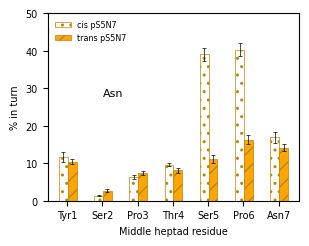

In [61]:
plt.figure()

x = ["Tyr1","Ser2","Pro3","Thr4","Ser5","Pro6","Asn7"]
x_axis = np.arange(len(x))
plt.bar(x_axis - 0.11 ,mid_ctd_phos_pro13_cis_turn_all_final.loc['mean']*100,0.25, yerr = mid_ctd_phos_pro13_cis_turn_all_final.loc['sem']*100, label = 'cis pS5N7', error_kw={'elinewidth': 0.5, "capsize": 1.5, "capthick": 0.5}, linewidth=0.5, edgecolor='darkgoldenrod',color = 'orange',fill=None,hatch='..')
plt.bar(x_axis + 0.14,mid_ctd_phos_pro13_trans_turn_all_final.loc['mean']*100,0.25, yerr = mid_ctd_phos_pro13_trans_turn_all_final.loc['sem']*100, label = 'trans pS5N7', error_kw={'elinewidth': 0.5, "capsize": 1.5, "capthick": 0.5}, linewidth=0.5, color = 'orange',hatch='//',edgecolor='darkgoldenrod')
plt.xticks(x_axis, x)
plt.legend(loc = "upper left", fontsize = 5.75, frameon = False)
plt.ylabel("% in turn", fontsize=7)
plt.xlabel("Middle heptad residue", fontsize=7)
plt.text(1, 30, 'Asn', fontsize=8, verticalalignment='top')
plt.xticks(fontsize = 7)
plt.yticks(fontsize = 7)
plt.ylim(top=50)  
plt.ylim(bottom=0)
#plt.title("Turn Character (phosphorylated)")

# Get the current figure
fig = plt.gcf()

# Get the current dimensions
current_width, current_height = fig.get_size_inches()
print(f"Current dimensions: {current_width} x {current_height} inches")

# Define the new width
new_width = 3.25

# Calculate the new height to maintain the aspect ratio
aspect_ratio = current_height / current_width
new_height = new_width * aspect_ratio
print(f"New dimensions: {new_width} x {new_height} inches")

# Set the new figure size
fig.set_size_inches(new_width, new_height)

# Save the figure
plt.savefig('p_asn_turn_cistrans_3.25in.png', dpi=300, bbox_inches='tight')

plt.show()

Current dimensions: 6.4 x 4.8 inches
New dimensions: 3.25 x 2.4374999999999996 inches


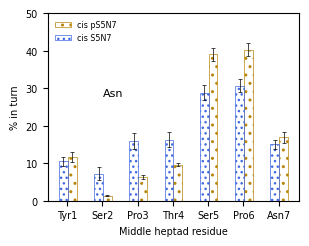

In [63]:
x = ["Tyr1","Ser2","Pro3","Thr4","Ser5","Pro6","Asn7"]
x_axis = np.arange(len(x))
plt.bar(x_axis + 0.14,mid_ctd_phos_pro13_cis_turn_all_final.loc['mean']*100,0.25, yerr = mid_ctd_phos_pro13_cis_turn_all_final.loc['sem']*100, label = 'cis pS5N7', error_kw={'elinewidth': 0.5, "capsize": 1.5, "capthick": 0.5}, linewidth=0.5, color='orange',hatch='..',edgecolor='darkgoldenrod',fill=None)
plt.bar(x_axis - 0.11 ,mid_ctd_pro13_cis_turn_all_final.loc['mean']*100,0.25, yerr = mid_ctd_pro13_cis_turn_all_final.loc['sem']*100, label = 'cis S5N7', error_kw={'elinewidth': 0.5, "capsize": 1.5, "capthick": 0.5}, linewidth=0.5, color='royalblue',fill=None,hatch='...',edgecolor='royalblue')
plt.xticks(x_axis, x)
plt.legend(loc = "upper left", fontsize = 5.75, frameon=False)
plt.ylabel("% in turn", fontsize=7)
plt.xlabel("Middle heptad residue", fontsize=7)
plt.ylim(top=50)  
plt.ylim(bottom=0)
plt.text(1, 30, 'Asn', fontsize=8, verticalalignment='top')
plt.xticks(fontsize = 7)
plt.yticks(fontsize = 7)
#plt.title("CTD Turn Character (Pro13-cis)")

# Get the current figure
fig = plt.gcf()

# Get the current dimensions
current_width, current_height = fig.get_size_inches()
print(f"Current dimensions: {current_width} x {current_height} inches")

# Define the new width
new_width = 3.25

# Calculate the new height to maintain the aspect ratio
aspect_ratio = current_height / current_width
new_height = new_width * aspect_ratio
print(f"New dimensions: {new_width} x {new_height} inches")

# Set the new figure size
fig.set_size_inches(new_width, new_height)

# Save the figure
plt.savefig('p_vs_up_asn_turn_cis_3.25in.png', dpi=300, bbox_inches='tight')

plt.show()

Current dimensions: 6.4 x 4.8 inches
New dimensions: 3.25 x 2.4374999999999996 inches


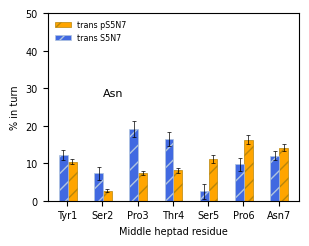

In [64]:
plt.figure()

x = ["Tyr1","Ser2","Pro3","Thr4","Ser5","Pro6","Asn7"]
x_axis = np.arange(len(x))
plt.bar(x_axis + 0.14, mid_ctd_phos_pro13_trans_turn_all_final.loc['mean']*100,0.25, yerr = mid_ctd_phos_pro13_trans_turn_all_final.loc['sem']*100, label = 'trans pS5N7', error_kw={'elinewidth': 0.5, "capsize": 1.5, "capthick": 0.5}, linewidth=0.5, color = 'orange',hatch='//',edgecolor='darkgoldenrod')
plt.bar(x_axis - 0.11 ,mid_ctd_pro13_trans_turn_all_final.loc['mean']*100,0.25, yerr = mid_ctd_pro13_cis_turn_all_final.loc['sem']*100, label = 'trans S5N7', error_kw={'elinewidth': 0.5, "capsize": 1.5, "capthick": 0.5}, linewidth=0.5, color = 'royalblue',hatch='//',edgecolor='lightsteelblue')
plt.xticks(x_axis, x)
plt.legend(loc = "upper left", fontsize = 5.75, frameon=False)
plt.ylabel("% in turn", fontsize=7)
plt.xlabel("Middle heptad residue", fontsize=7)
plt.ylim(top=50)  
plt.ylim(bottom=0)
#plt.title("CTD Turn Character (Pro13-trans)")

plt.text(1, 30, 'Asn', fontsize=8, verticalalignment='top')
plt.xticks(fontsize = 7)
plt.yticks(fontsize = 7)
#plt.title("CTD Turn Character (Pro13-trans)")

# Get the current figure
fig = plt.gcf()

# Get the current dimensions
current_width, current_height = fig.get_size_inches()
print(f"Current dimensions: {current_width} x {current_height} inches")

# Define the new width
new_width = 3.25

# Calculate the new height to maintain the aspect ratio
aspect_ratio = current_height / current_width
new_height = new_width * aspect_ratio
print(f"New dimensions: {new_width} x {new_height} inches")

# Set the new figure size
fig.set_size_inches(new_width, new_height)

# Save the figure
plt.savefig('p_vs_up_asn_turn_trans_3.25in.png', dpi=300, bbox_inches='tight')

plt.show()

Current dimensions: 6.4 x 4.8 inches
New dimensions: 3.25 x 2.4374999999999996 inches


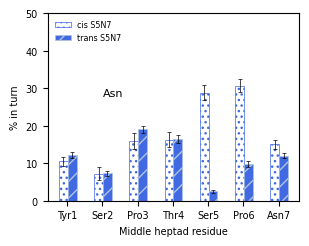

In [65]:
plt.figure()

x = ["Tyr1","Ser2","Pro3","Thr4","Ser5","Pro6","Asn7"]

x_axis = np.arange(len(x))

plt.bar(x_axis - 0.11,mid_ctd_pro13_cis_turn_all_final.loc['mean']*100,0.25, yerr = mid_ctd_pro13_cis_turn_all_final.loc['sem']*100, error_kw={'elinewidth': 0.5, "capsize": 1.5, "capthick": 0.5}, linewidth=0.5, label = 'cis S5N7' , color='royalblue',fill=None,hatch='...',edgecolor='royalblue')
plt.bar(x_axis + 0.14 ,mid_ctd_pro13_trans_turn_all_final.loc['mean']*100,0.25, yerr = mid_ctd_pro13_trans_turn_all_final.loc['sem']*100, error_kw={'elinewidth': 0.5, "capsize": 1.5, "capthick": 0.5}, linewidth=0.5, label = 'trans S5N7', color = 'royalblue',hatch='//',edgecolor='lightsteelblue')
plt.xticks(x_axis, x)
plt.legend(loc = "upper left", fontsize = 5.75, frameon = False)
plt.ylabel("% in turn", fontsize=7)
plt.xlabel("Middle heptad residue", fontsize=7)
plt.ylim(top=50)  
plt.ylim(bottom=0)
#plt.title("Turn Character (unphosphorylated)")

plt.text(1, 30, 'Asn', fontsize=8, verticalalignment='top')
plt.xticks(fontsize = 7)
plt.yticks(fontsize = 7)
#plt.title("Turn Character (unphosphorylated)")

# Get the current figure
fig = plt.gcf()

# Get the current dimensions
current_width, current_height = fig.get_size_inches()
print(f"Current dimensions: {current_width} x {current_height} inches")

# Define the new width
new_width = 3.25

# Calculate the new height to maintain the aspect ratio
aspect_ratio = current_height / current_width
new_height = new_width * aspect_ratio
print(f"New dimensions: {new_width} x {new_height} inches")

# Set the new figure size
fig.set_size_inches(new_width, new_height)

# Save the figure
plt.savefig('asn_turn_cistrans_3.25in.png', dpi=300, bbox_inches='tight')

plt.show()

# Turn content across entire peptide, unphos vs phos

In [68]:
# Define column names
columns = ['unphos', 'phos']

# Create an empty DataFrame with 2 rows and 5 columns
pro13_turn_percents = pd.DataFrame(np.nan, index=range(nsim), columns=columns)

print(pro13_turn_percents)

   unphos  phos
0     NaN   NaN
1     NaN   NaN
2     NaN   NaN
3     NaN   NaN
4     NaN   NaN
5     NaN   NaN
6     NaN   NaN
7     NaN   NaN
8     NaN   NaN
9     NaN   NaN


In [69]:
i = 0
for sim in secstruc_cistrans_sim_list:
        
    weights = sim['weights'].sum()

    res_turn_prct = 0
    for col in sim.iloc[:,2:-3]:
        res_turn_prct += ((sim[col] =='T')*sim['weights']).sum()/weights

    mean_turn_prct = res_turn_prct/len(sim.iloc[:,2:-3].columns)
    pro13_turn_percents.at[i, 'unphos'] = mean_turn_prct
    
    i += 1

In [70]:
pro13_turn_percents

,unphos,phos
0,0.107680,NaN
1,0.097846,NaN
2,0.107675,NaN
3,0.103914,NaN
4,0.104317,NaN
5,0.111832,NaN
6,0.110141,NaN
7,0.094404,NaN
8,0.093476,NaN
9,0.108579,NaN


In [71]:
i = 0
for sim in phos_secstruc_cistrans_sim_list:
        
    weights = sim['weights'].sum()

    res_turn_prct = 0
    for col in sim.iloc[:,2:-3]:
        res_turn_prct += ((sim[col] =='T')*sim['weights']).sum()/weights

    mean_turn_prct = res_turn_prct/len(sim.iloc[:,2:-3].columns)
    pro13_turn_percents.at[i, 'phos'] = mean_turn_prct
    
    i += 1

In [72]:
pro13_turn_percents

,unphos,phos
0,0.107680,0.116508
1,0.097846,0.088360
2,0.107675,0.081672
3,0.103914,0.115419
4,0.104317,0.099095
5,0.111832,0.099544
6,0.110141,0.113770
7,0.094404,0.103957
8,0.093476,0.106089
9,0.108579,0.100716


In [73]:
# Calculate the SEM (standard error of the mean)
mean_values = pro13_turn_percents.mean()
sem_values = pro13_turn_percents.sem()

# Append as a new row labeled 'sem'
df_with_mean = pd.concat([pro13_turn_percents, pd.DataFrame([mean_values], index=['mean'])])
pro13_turn_percents_final = pd.concat([df_with_mean, pd.DataFrame([sem_values], index=['sem'])])

In [74]:
pro13_turn_percents_final

,unphos,phos
0,0.107680,0.116508
1,0.097846,0.088360
2,0.107675,0.081672
3,0.103914,0.115419
4,0.104317,0.099095
5,0.111832,0.099544
6,0.110141,0.113770
7,0.094404,0.103957
8,0.093476,0.106089
9,0.108579,0.100716


(0.0, 15.0)

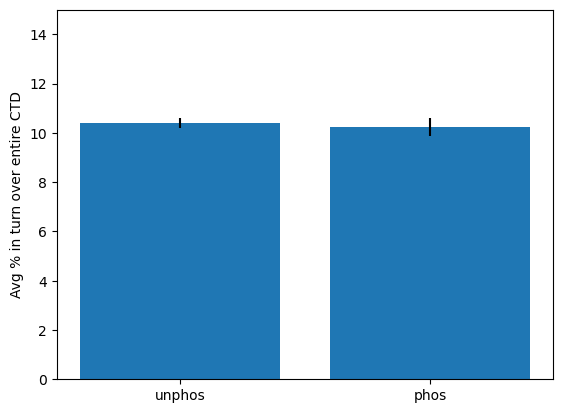

In [75]:
x = ["unphos","phos"]

x_axis = np.arange(len(x))

plt.bar(x_axis,pro13_turn_percents_final.loc['mean']*100, yerr = pro13_turn_percents_final.loc['sem']*100, label = 'Pro6 in Cis' )
#plt.bar(x_axis + 0.14 ,mid_ctd_pro13_trans_turn_all_final.loc['mean']*100,0.25, yerr = mid_ctd_pro13_trans_turn_all_final.loc['sem']*100, label = 'Pro6 in Trans', color = 'blue',hatch='//',edgecolor='lightsteelblue')
plt.xticks(x_axis, x)
#plt.legend(loc = "upper left", fontsize = 11, frameon = False)
plt.ylabel("Avg % in turn over entire CTD")
plt.ylim(top=15)  
plt.ylim(bottom=0)


# Cis percentage of just Pro6 looking at all frames where Pro6 is in turn, unphos vs phos

In [76]:
# Define column names
columns = ['unphos', 'phos']

# Create an empty DataFrame with 2 rows and 5 columns
pro13_turn_cis_percents = pd.DataFrame(np.nan, index=range(nsim), columns=columns)

print(pro13_turn_cis_percents)

   unphos  phos
0     NaN   NaN
1     NaN   NaN
2     NaN   NaN
3     NaN   NaN
4     NaN   NaN
5     NaN   NaN
6     NaN   NaN
7     NaN   NaN
8     NaN   NaN
9     NaN   NaN


## Unphosphorylated

In [77]:
i = 0
for sim in secstruc_cistrans_sim_list:
    
    pro6_turn_true = ((sim['PRO:14'] == 'T')*sim['weights']).sum()
    
    sim_mean = (((sim['PRO:14'] == 'T') & (sim['cis/trans/neither'] == 'cis'))*sim['weights']).sum()/pro6_turn_true
    pro13_turn_cis_percents.at[i, 'unphos'] = sim_mean

    
    i += 1

In [78]:
pro13_turn_cis_percents

,unphos,phos
0,0.362441,NaN
1,0.312994,NaN
2,0.337362,NaN
3,0.429551,NaN
4,0.197803,NaN
5,0.304786,NaN
6,0.280087,NaN
7,0.476988,NaN
8,0.285092,NaN
9,0.386089,NaN


In [79]:
i = 0
for sim in phos_secstruc_cistrans_sim_list:
    
    pro6_turn_true = ((sim['PRO:14'] == 'T')*sim['weights']).sum()
    
    sim_mean = (((sim['PRO:14'] == 'T') & (sim['cis/trans/neither'] == 'cis'))*sim['weights']).sum()/pro6_turn_true
    pro13_turn_cis_percents.at[i, 'phos'] = sim_mean

    
    i += 1

In [80]:
pro13_turn_cis_percents

,unphos,phos
0,0.362441,0.355751
1,0.312994,0.448948
2,0.337362,0.468954
3,0.429551,0.441768
4,0.197803,0.426630
5,0.304786,0.349426
6,0.280087,0.542219
7,0.476988,0.534456
8,0.285092,0.508364
9,0.386089,0.464005


In [81]:
# Calculate the SEM (standard error of the mean)
mean_values = pro13_turn_cis_percents.mean()
sem_values = pro13_turn_cis_percents.sem()

# Append as a new row labeled 'sem'
df_with_mean = pd.concat([pro13_turn_cis_percents, pd.DataFrame([mean_values], index=['mean'])])
pro13_turn_cis_percents_final = pd.concat([df_with_mean, pd.DataFrame([sem_values], index=['sem'])])

In [82]:
pro13_turn_cis_percents_final

,unphos,phos
0,0.362441,0.355751
1,0.312994,0.448948
2,0.337362,0.468954
3,0.429551,0.441768
4,0.197803,0.426630
5,0.304786,0.349426
6,0.280087,0.542219
7,0.476988,0.534456
8,0.285092,0.508364
9,0.386089,0.464005


Text(0.5, 1.0, 'Pro6 in Turn')

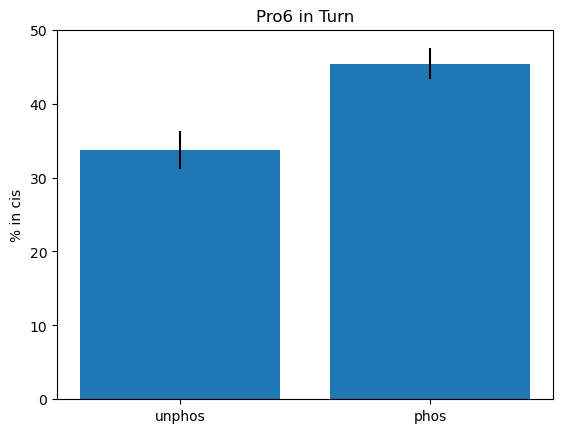

In [83]:
x = ["unphos","phos"]

x_axis = np.arange(len(x))

plt.bar(x_axis,pro13_turn_cis_percents_final.loc['mean']*100, yerr = pro13_turn_cis_percents_final.loc['sem']*100, label = 'Pro6 in Cis' )
#plt.bar(x_axis + 0.14 ,mid_ctd_pro13_trans_turn_all_final.loc['mean']*100,0.25, yerr = mid_ctd_pro13_trans_turn_all_final.loc['sem']*100, label = 'Pro6 in Trans', color = 'blue',hatch='//',edgecolor='lightsteelblue')
plt.xticks(x_axis, x)
#plt.legend(loc = "upper left", fontsize = 11, frameon = False)
plt.ylabel("% in cis")
plt.ylim(top=50)  
plt.ylim(bottom=0)
plt.title("Pro6 in Turn")


# Cis percentages

## Unphosphorylated

In [16]:
ctd_omega_angles.to_csv('asn_unphos_omega_angles.csv', index=False)

In [66]:
cistrans_sim_list = np.array_split(ctd_omega_angles, nsim)

/cm/shared/apps/anaconda3/python3.12/lib/python3.12/site-packages/numpy/core/fromnumeric.py:59: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


In [67]:
# Define column names
columns = ['Pro3', 'Pro6', 'Pro10', 'Pro13', 'Pro17', 'Pro20']

# Create an empty DataFrame with 2 rows and 5 columns
cis_percents = pd.DataFrame(np.nan, index=range(nsim), columns=columns)
cis_weights = pd.DataFrame(np.nan, index=range(nsim), columns=columns)

print(cis_percents)

   Pro3  Pro6  Pro10  Pro13  Pro17  Pro20
0   NaN   NaN    NaN    NaN    NaN    NaN
1   NaN   NaN    NaN    NaN    NaN    NaN
2   NaN   NaN    NaN    NaN    NaN    NaN
3   NaN   NaN    NaN    NaN    NaN    NaN
4   NaN   NaN    NaN    NaN    NaN    NaN
5   NaN   NaN    NaN    NaN    NaN    NaN
6   NaN   NaN    NaN    NaN    NaN    NaN
7   NaN   NaN    NaN    NaN    NaN    NaN
8   NaN   NaN    NaN    NaN    NaN    NaN
9   NaN   NaN    NaN    NaN    NaN    NaN


In [69]:
i = 0
for sim in cistrans_sim_list:

    sim_weight_total = sim['weights'].sum()
    
    sim_mean = (((sim['omega:4'] == 'cis'))*sim['weights']).sum()/sim_weight_total
    cis_percents.at[i, 'Pro3'] = sim_mean
    cis_weights.at[i, 'Pro3'] = sim_weight_total
    sim_mean = (((sim['omega:7'] == 'cis'))*sim['weights']).sum()/sim_weight_total
    cis_percents.at[i, 'Pro6'] = sim_mean
    cis_weights.at[i, 'Pro6'] = sim_weight_total
    sim_mean = (((sim['omega:11'] == 'cis'))*sim['weights']).sum()/sim_weight_total
    cis_percents.at[i, 'Pro10'] = sim_mean
    cis_weights.at[i, 'Pro10'] = sim_weight_total
    sim_mean = (((sim['omega:14'] == 'cis'))*sim['weights']).sum()/sim_weight_total
    cis_percents.at[i, 'Pro13'] = sim_mean
    cis_weights.at[i, 'Pro13'] = sim_weight_total
    sim_mean = (((sim['omega:18'] == 'cis'))*sim['weights']).sum()/sim_weight_total
    cis_percents.at[i, 'Pro17'] = sim_mean
    cis_weights.at[i, 'Pro17'] = sim_weight_total
    sim_mean = (((sim['omega:21'] == 'cis'))*sim['weights']).sum()/sim_weight_total
    cis_percents.at[i, 'Pro20'] = sim_mean
    cis_weights.at[i, 'Pro20'] = sim_weight_total
    
    i += 1

In [70]:
cis_percents

,Pro3,Pro6,Pro10,Pro13,Pro17,Pro20
0,0.093412,0.166176,0.121018,0.206326,0.136418,0.123897
1,0.083365,0.131481,0.112619,0.137381,0.111290,0.138246
2,0.068432,0.130149,0.101416,0.157396,0.128522,0.124930
3,0.098217,0.097337,0.125088,0.158116,0.107624,0.118431
4,0.090626,0.128735,0.114042,0.100198,0.075641,0.126004
5,0.089521,0.159998,0.132100,0.113912,0.119804,0.115566
6,0.113859,0.103272,0.143766,0.137315,0.096194,0.087895
7,0.072278,0.153485,0.138767,0.160726,0.105410,0.095982
8,0.093365,0.142601,0.094716,0.124449,0.147136,0.108951
9,0.073953,0.151436,0.098700,0.168388,0.095053,0.119585


In [71]:
# Calculate the SEM (standard error of the mean)
mean_list = []
sem_list = []
for i in range(6):
    print(i)
    mean_list.append(weighted_mean_and_se(cis_percents.iloc[:,i].tolist(), cis_weights.iloc[:,i].tolist())[0])
    sem_list.append(weighted_mean_and_se(cis_percents.iloc[:,i].tolist(), cis_weights.iloc[:,i].tolist())[1])

0
1
2
3
4
5


In [72]:
df_with_mean = pd.concat([cis_percents, pd.DataFrame([mean_list], index=['mean'], columns=columns)])
cis_percents_final = pd.concat([df_with_mean, pd.DataFrame([sem_list], index=['sem'], columns=columns)])

In [ ]:
cis_percents_final

# Phosphorylated

In [ ]:
#ctd_phos_omega_angles.to_csv('asn_phos_omega_angles.csv', index=False)

In [73]:
phos_cistrans_sim_list = np.array_split(ctd_phos_omega_angles, nsim)

/cm/shared/apps/anaconda3/python3.12/lib/python3.12/site-packages/numpy/core/fromnumeric.py:59: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


In [74]:
# Define column names
columns = ['Pro3', 'Pro6', 'Pro10', 'Pro13', 'Pro17', 'Pro20']

# Create an empty DataFrame with 2 rows and 5 columns
phos_cis_percents = pd.DataFrame(np.nan, index=range(nsim), columns=columns)
phos_cis_weights = pd.DataFrame(np.nan, index=range(nsim), columns=columns)

print(phos_cis_percents)

   Pro3  Pro6  Pro10  Pro13  Pro17  Pro20
0   NaN   NaN    NaN    NaN    NaN    NaN
1   NaN   NaN    NaN    NaN    NaN    NaN
2   NaN   NaN    NaN    NaN    NaN    NaN
3   NaN   NaN    NaN    NaN    NaN    NaN
4   NaN   NaN    NaN    NaN    NaN    NaN
5   NaN   NaN    NaN    NaN    NaN    NaN
6   NaN   NaN    NaN    NaN    NaN    NaN
7   NaN   NaN    NaN    NaN    NaN    NaN
8   NaN   NaN    NaN    NaN    NaN    NaN
9   NaN   NaN    NaN    NaN    NaN    NaN


In [75]:
i = 0
for sim in phos_cistrans_sim_list:

    sim_weight_total = sim['weights'].sum()
    
    sim_mean = (((sim['omega:4'] == 'cis'))*sim['weights']).sum()/sim_weight_total
    phos_cis_percents.at[i, 'Pro3'] = sim_mean
    phos_cis_weights.at[i, 'Pro3'] = sim_weight_total
    sim_mean = (((sim['omega:7'] == 'cis'))*sim['weights']).sum()/sim_weight_total
    phos_cis_percents.at[i, 'Pro6'] = sim_mean
    phos_cis_weights.at[i, 'Pro6'] = sim_weight_total
    sim_mean = (((sim['omega:11'] == 'cis'))*sim['weights']).sum()/sim_weight_total
    phos_cis_percents.at[i, 'Pro10'] = sim_mean
    phos_cis_weights.at[i, 'Pro10'] = sim_weight_total
    sim_mean = (((sim['omega:14'] == 'cis'))*sim['weights']).sum()/sim_weight_total
    phos_cis_percents.at[i, 'Pro13'] = sim_mean
    phos_cis_weights.at[i, 'Pro13'] = sim_weight_total
    sim_mean = (((sim['omega:18'] == 'cis'))*sim['weights']).sum()/sim_weight_total
    phos_cis_percents.at[i, 'Pro17'] = sim_mean
    phos_cis_weights.at[i, 'Pro17'] = sim_weight_total
    sim_mean = (((sim['omega:21'] == 'cis'))*sim['weights']).sum()/sim_weight_total
    phos_cis_percents.at[i, 'Pro20'] = sim_mean
    phos_cis_weights.at[i, 'Pro20'] = sim_weight_total
    
    i += 1

In [76]:
phos_cis_percents

,Pro3,Pro6,Pro10,Pro13,Pro17,Pro20
0,0.083765,0.264588,0.081410,0.229755,0.067365,0.175029
1,0.064250,0.192638,0.061496,0.258000,0.066977,0.146907
2,0.062272,0.209877,0.071512,0.260896,0.089328,0.199494
3,0.049043,0.247650,0.074962,0.268835,0.074170,0.186820
4,0.088032,0.217988,0.077016,0.245635,0.084512,0.195212
5,0.100405,0.244876,0.066340,0.194852,0.068247,0.176121
6,0.083921,0.178032,0.075444,0.279278,0.086422,0.229621
7,0.068804,0.342815,0.062479,0.316293,0.085231,0.193790
8,0.064902,0.257543,0.048989,0.290429,0.065697,0.150823
9,0.060484,0.216532,0.071024,0.260340,0.111072,0.225750


In [77]:
mean_list = []
sem_list = []
for i in range(6):
    print(i)
    mean_list.append(weighted_mean_and_se(phos_cis_percents.iloc[:,i].tolist(), phos_cis_weights.iloc[:,i].tolist())[0])
    sem_list.append(weighted_mean_and_se(phos_cis_percents.iloc[:,i].tolist(), phos_cis_weights.iloc[:,i].tolist())[1])

0
1
2
3
4
5


In [78]:
df_with_mean = pd.concat([phos_cis_percents, pd.DataFrame([mean_list], index=['mean'], columns=columns)])
phos_cis_percents_final = pd.concat([df_with_mean, pd.DataFrame([sem_list], index=['sem'], columns=columns)])

In [79]:
phos_cis_percents_final

,Pro3,Pro6,Pro10,Pro13,Pro17,Pro20
0,0.083765,0.264588,0.081410,0.229755,0.067365,0.175029
1,0.064250,0.192638,0.061496,0.258000,0.066977,0.146907
2,0.062272,0.209877,0.071512,0.260896,0.089328,0.199494
3,0.049043,0.247650,0.074962,0.268835,0.074170,0.186820
4,0.088032,0.217988,0.077016,0.245635,0.084512,0.195212
5,0.100405,0.244876,0.066340,0.194852,0.068247,0.176121
6,0.083921,0.178032,0.075444,0.279278,0.086422,0.229621
7,0.068804,0.342815,0.062479,0.316293,0.085231,0.193790
8,0.064902,0.257543,0.048989,0.290429,0.065697,0.150823
9,0.060484,0.216532,0.071024,0.260340,0.111072,0.225750


Current dimensions: 6.4 x 4.8 inches
New dimensions: 3.25 x 2.4374999999999996 inches


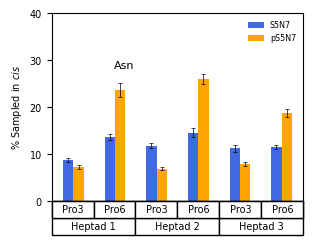

In [80]:
fig = plt.figure

x = ['Pro3','Pro6','Pro3','Pro6','Pro3','Pro6']
h = ['Heptad 1', "Heptad 2", "Heptad 3"]

x_axis = np.arange(len(x))

plt.bar(x_axis - 0.11,cis_percents_final.loc["mean"].apply(lambda f:f*100),0.25, error_kw={'elinewidth': 0.5, "capsize": 1.5, "capthick": 0.5}, align='center', label = 'S5N7', color = 'royalblue', yerr = cis_percents_final.loc["sem"].apply(lambda f:f*100)) 
plt.bar(x_axis + 0.14,phos_cis_percents_final.loc["mean"].apply(lambda f:f*100),0.25, error_kw={'elinewidth': 0.5, "capsize": 1.5, "capthick": 0.5}, align='center', label = 'pS5N7', color = 'orange', yerr = phos_cis_percents_final.loc["sem"].apply(lambda f:f*100)) # A bar chart
plt.xticks(x_axis, x, fontsize = 7)
plt.yticks(fontsize=7)
plt.tick_params(labelbottom=False)
plt.legend(fontsize = 5.75, frameon=False)
#plt.title('Proline $\it{cis}$ Sampled In CTD')
plt.ylabel("% Sampled in $\it{cis}$", fontsize=7)
plt.ylim(0,40)
plt.text(1, 30, 'Asn', fontsize=8, verticalalignment='top')
# this is dumb and no one should do it like this but I have to because SOMEONE didn't make this table its own figure :p
tabl = plt.table(cellText=[x], loc="bottom", cellLoc='center')
tabl2 = plt.table(cellText=[["","",""], h], loc="bottom", cellLoc='center')
tabl.set_fontsize(7)
tabl2.set_fontsize(7)

tabl.scale(1,2)
tabl.zorder = 2
tabl2.scale(1,2)
tabl2.zorder = 1

# Get the current figure
fig = plt.gcf()

# Get the current dimensions
current_width, current_height = fig.get_size_inches()
print(f"Current dimensions: {current_width} x {current_height} inches")

# Define the new width
new_width = 3.25

# Calculate the new height to maintain the aspect ratio
aspect_ratio = current_height / current_width
new_height = new_width * aspect_ratio
print(f"New dimensions: {new_width} x {new_height} inches")

# Set the new figure size
fig.set_size_inches(new_width, new_height)

# Save the figure
plt.savefig('cis_percentage_asn.png', dpi=300, bbox_inches='tight')

plt.show()

In [53]:
# --- 1. Define Setup and Placeholder Data (Replace with your actual data) ---
group1_data = cis_percents
group2_data = phos_cis_percents

# Weights are now DataFrames (10 rows x 6 columns)
# Note: For the permutation test to work, the weights in each column must correspond to the data in that column.
group1_weights = cis_weights
group2_weights = phos_cis_weights

# --- 2. Combine Data and Weights ---
both_groups = pd.concat([group1_data, group2_data], ignore_index=True) # 20x6 DataFrame
both_weights = pd.concat([group1_weights, group2_weights], ignore_index=True) # 20x6 DataFrame

# Total number of simulations (i.e., rows) in the original groups
num_sims = len(group1_data) # This will be 10

# Normalize the combined weights (column-wise)
# Each weight column is normalized separately to sum to 1.
both_p = both_weights / both_weights.sum(axis=0)

# --- 3. Calculate the Observed Weighted Difference (per column) ---
original_diff_means = {}
for col in both_groups.columns:
    # Use the weights specific to the current column
    group1_w_mean = np.average(group1_data[col], weights=group1_weights[col])
    group2_w_mean = np.average(group2_data[col], weights=group2_weights[col])

    if group2_w_mean > group1_w_mean:
        group2_greater = True
        original_diff_means[col] = group2_w_mean - group1_w_mean
    else:
        group2_greater = False
        original_diff_means[col] = group1_w_mean - group2_w_mean

# --- 4. Perform the Permutation Test (per column) ---
numsample = 10000
results_p_value = {}

# Iterate over each column (the test is independent for each column)
for col in both_groups.columns:
    # Extract the data and the weights for the current column as arrays
    both_col_data = both_groups[col].values
    both_col_weights = both_p[col].values
    original_diff = original_diff_means[col]
    
    diff_samples_col = np.zeros(numsample)
    diff_samples_larger_col = np.zeros(numsample, dtype=int)
    
    # Run the permutation loop
    for sample in range(numsample):
        # Randomize data and weights using the same permutation 'p'
        p = np.random.permutation(len(both_groups))
        random_both_data = both_col_data[p]
        random_weights = both_col_weights[p]
        
        # Calculate the weighted mean difference for the permuted split
        # Group A: First 10 rows (0 to num_sims)
        group_A_w_mean = np.average(random_both_data[0:num_sims], weights=random_weights[0:num_sims])
        # Group B: Second 10 rows (num_sims to 2*num_sims)
        group_B_w_mean = np.average(random_both_data[num_sims:num_sims * 2], weights=random_weights[num_sims:num_sims * 2])

        if group2_greater == True:
            diff_samples_col[sample] = group_B_w_mean - group_A_w_mean
        else:
            diff_samples_col[sample] = group_A_w_mean - group_B_w_mean
        
        # Check if the permuted difference is as extreme or more extreme
        if diff_samples_col[sample] >= original_diff:
            diff_samples_larger_col[sample] = 1
            
    # Calculate the p-value
    p_value = (1 + np.sum(diff_samples_larger_col)) / (numsample + 1)
    results_p_value[col] = p_value

# --- 5. Print Results ---
print("### Permutation Test Results (Weighted Mean Difference) ###")
print(f"Number of Permutations: {numsample}\n")

for col, p_value in results_p_value.items():
    print(f"**{col}:**")
    print(f"  Observed Weighted Difference: {original_diff_means[col]:.4f}")
    print(f"  Calculated P-value: {p_value:.4f}")

### Permutation Test Results (Weighted Mean Difference) ###
Number of Permutations: 10000

**Pro3:**
  Observed Weighted Difference: 0.0153
  Calculated P-value: 0.0175
**Pro6:**
  Observed Weighted Difference: 0.1000
  Calculated P-value: 0.0001
**Pro10:**
  Observed Weighted Difference: 0.0493
  Calculated P-value: 0.0001
**Pro13:**
  Observed Weighted Difference: 0.1142
  Calculated P-value: 0.0001
**Pro17:**
  Observed Weighted Difference: 0.0325
  Calculated P-value: 0.0002
**Pro20:**
  Observed Weighted Difference: 0.0725
  Calculated P-value: 0.0002
